# RlLib pour le couloir

Jusqu'à présent nous avons fait usage de StableBaselines qui est très facile à utiliser.
Mais d'autres librairies existent, comme RLlib

## Importations

In [1]:
# LES ALGORITHMES
# Pour StableBaselines
from QLearning import *
from DQN import *
from PPO import *
from helperPlot import *

# Pour RLLib
from ray.rllib.algorithms.dqn import DQNConfig
from ray.rllib.connectors.env_to_module import FlattenObservations
from ray import train, tune
from rllib_helper import *

# Aide
import time
from pprint import pprint

# POUR AFFICHAGE
import matplotlib.pyplot as plt
import seaborn as sns

# POUR ENVIRONNEMENT
import gymnasium
from gymnasium import spaces

## Environnement

In [2]:
class LineWorldEnv(gymnasium.Env):
    def __init__(self, options = None):
        super(LineWorldEnv, self).__init__()
        n_states = options['n_states']
        self.n_states = n_states
        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Discrete(n_states)
        self.state = 0

    def reset(self, seed = None, options = None):
        super().reset(seed = seed)
        self.state = 0
        return self.state, {}

    def step(self, action):
        if action == 0 and self.state > 0:
            self.state -= 1
        elif action == 1 and self.state < self.n_states - 1:
            self.state += 1
        done = self.state == self.n_states - 1
        reward = 10 if done else -1
        return self.state, reward, done, False, {}

    def render(self):
        print("État actuel :", self.state)

## Entraînement DQN RLlib couloir taille 10

In [3]:
# Configure the algorithm.
config = (
    DQNConfig()
    .environment(
        LineWorldEnv,
        env_config = {'n_states' : 10},
    )
    
    .env_runners(
        # Observations are discrete (ints) -> We need to flatten (one-hot) them.
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    # Specify a simple tune hyperparameter sweep.
    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99])
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[2], [8], [16], [32]])
        }
    )
)



# Create a Tuner instance to manage the trials.
tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    # Specify a stopping criterion. Note that the criterion has to match one of the
    # pretty printed result metrics from the results returned previously by
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 10000},
    ),
)
# Run the Tuner and capture the results.
results = tuner.fit()


2025-06-13 16:02:49,391	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=54516) 2025-06-13 16:02:54,565	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=54516) 2025-06-13 16:02:55,217	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `

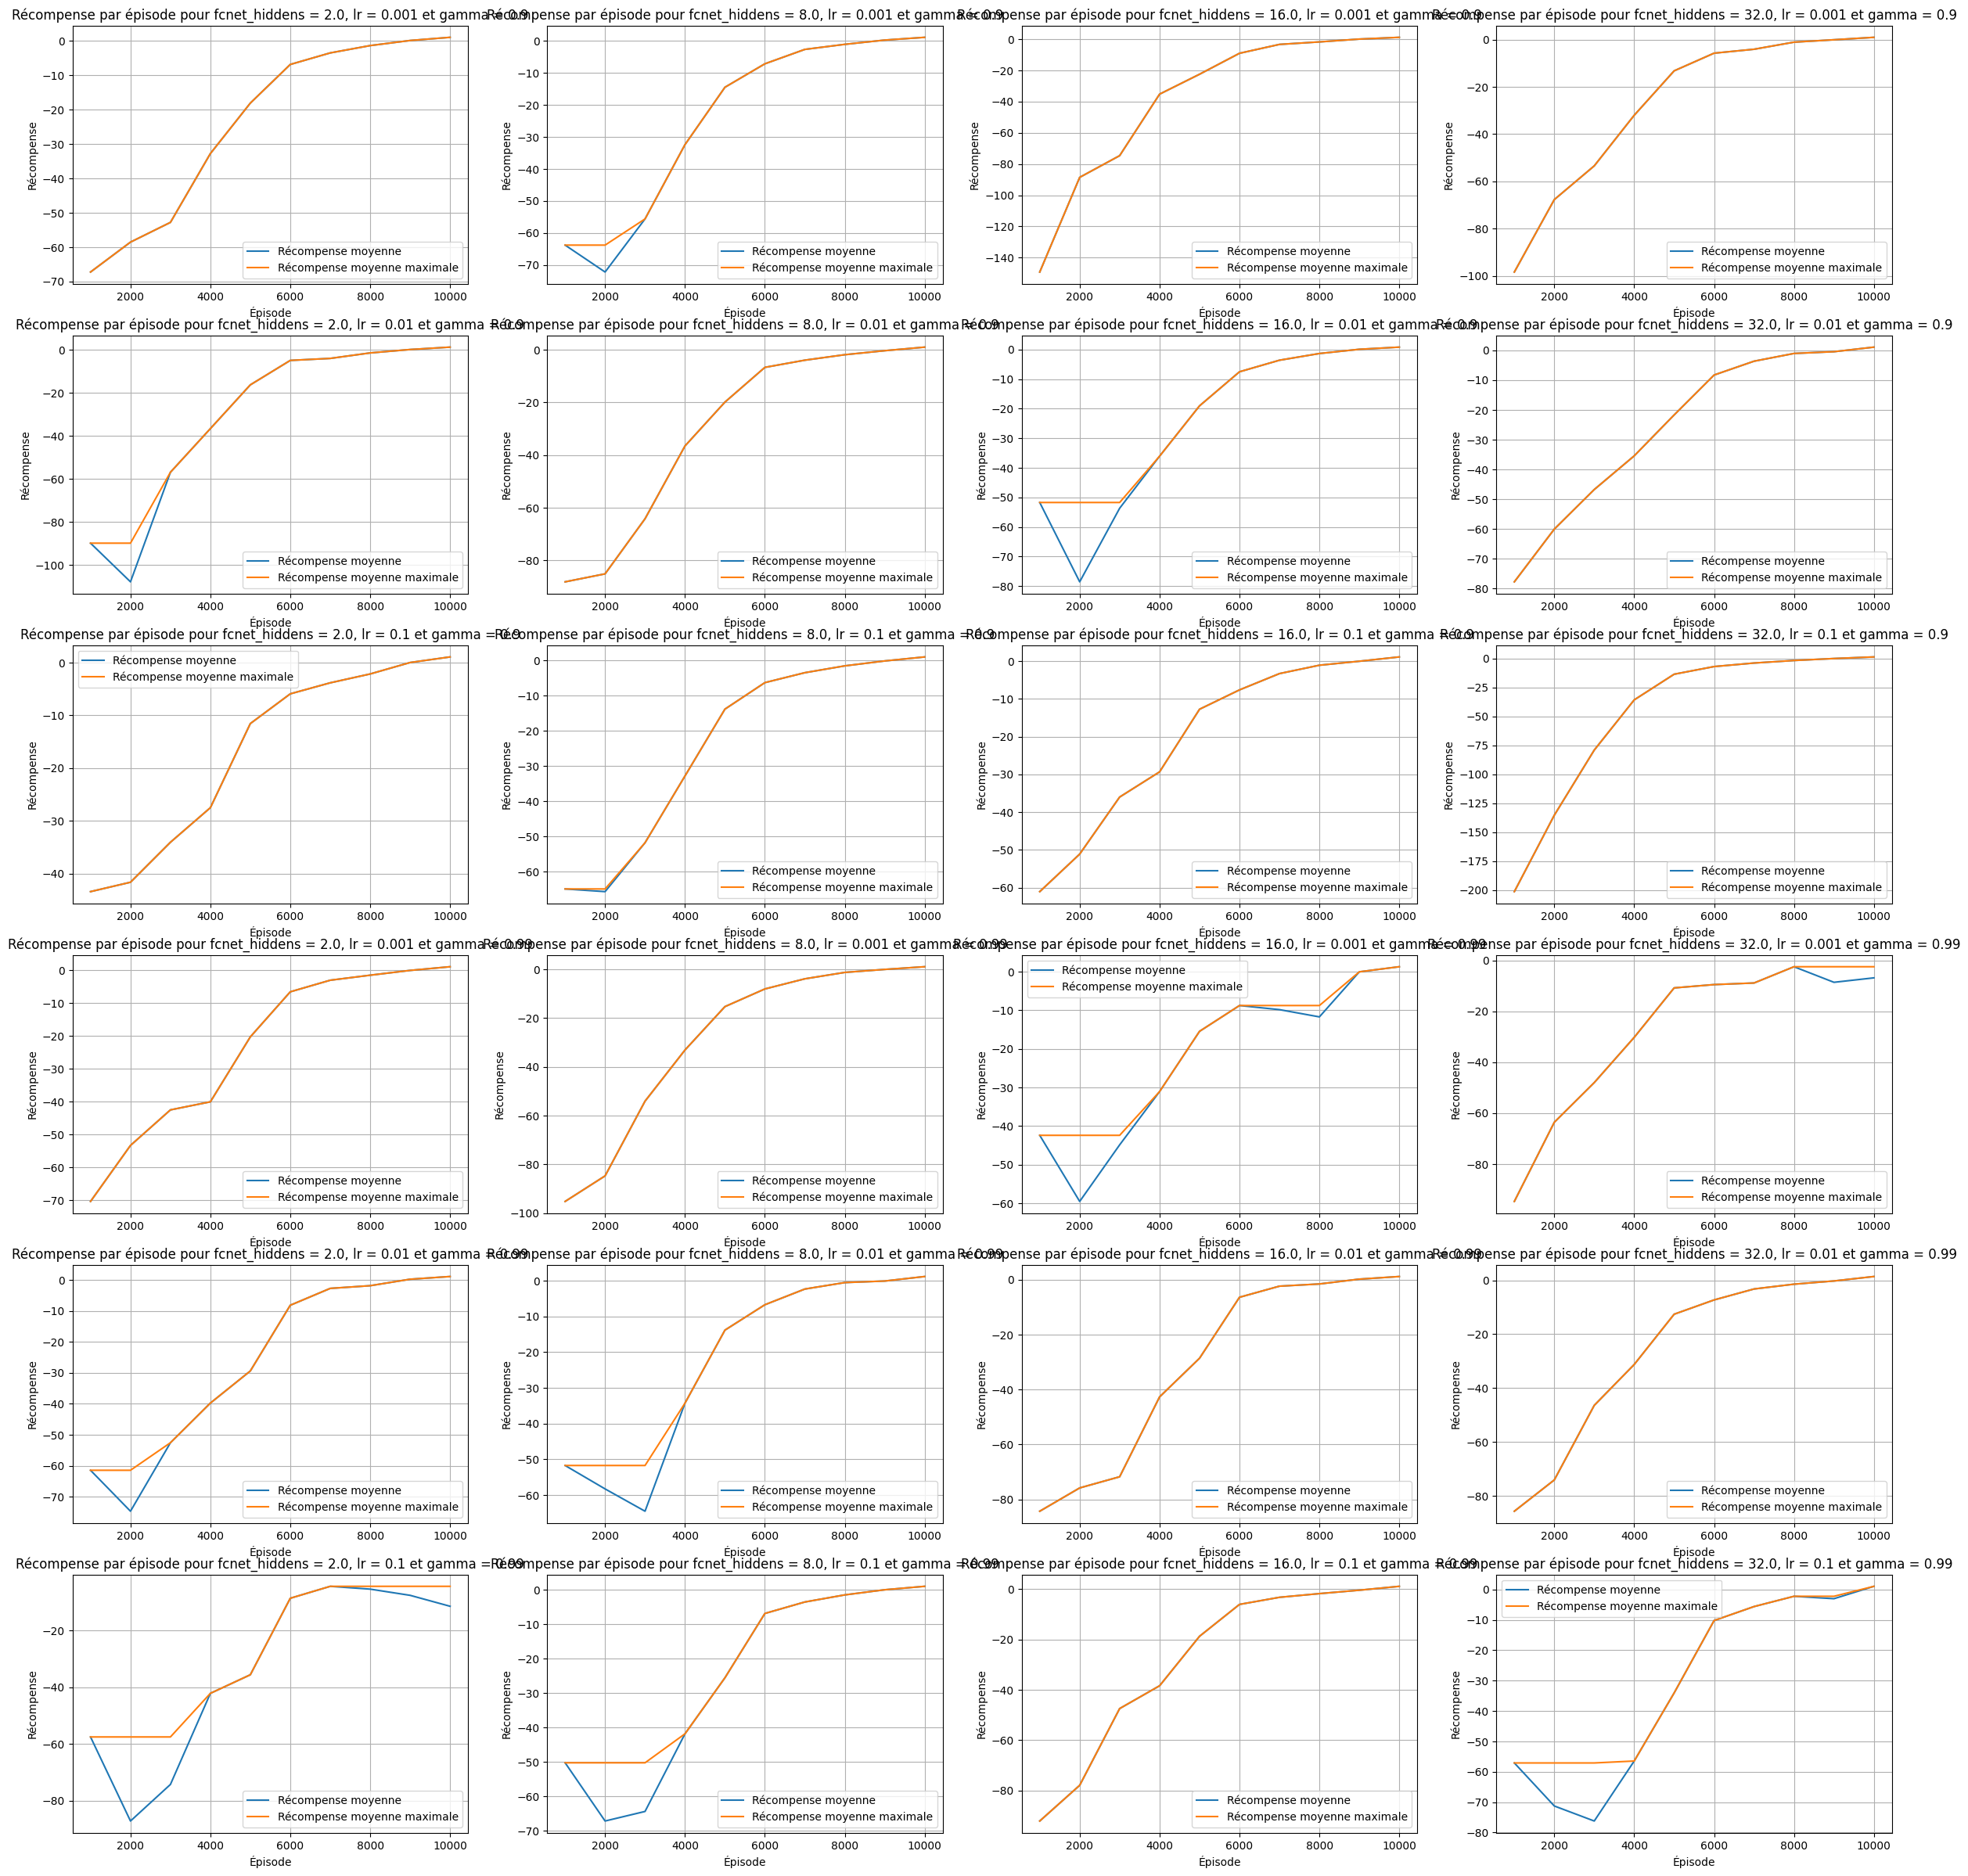

In [4]:
comparison_plot_3(results,
                  "fcnet_hiddens", [2., 8., 16., 32.],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99]
                 )

Meilleurs résultats obtenus pour :
- fcnet_hiddens = [2]
- lr = 0.001
- gamma = 0.99

## Entraînement DQN RLlib couloir taille 40

In [4]:
# Configure the algorithm.
config = (
    DQNConfig()
    .environment(
        LineWorldEnv,
        env_config = {'n_states' : 40},
    )
    
    .env_runners(
        # Observations are discrete (ints) -> We need to flatten (one-hot) them.
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    # Specify a simple tune hyperparameter sweep.
    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99])
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[2], [8], [16], [32]])
        }
    )
)



# Create a Tuner instance to manage the trials.
tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    # Specify a stopping criterion. Note that the criterion has to match one of the
    # pretty printed result metrics from the results returned previously by
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 10000},
    ),
)
# Run the Tuner and capture the results.
results = tuner.fit()

2025-06-15 20:55:39,197	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/thewalder/ray_results/DQN_2025-06-15_20-30-08' in 0.1726s.
2025-06-15 20:55:39,629	INFO tune.py:1041 -- Total run time: 1531.46 seconds (1530.85 seconds for the tuning loop).


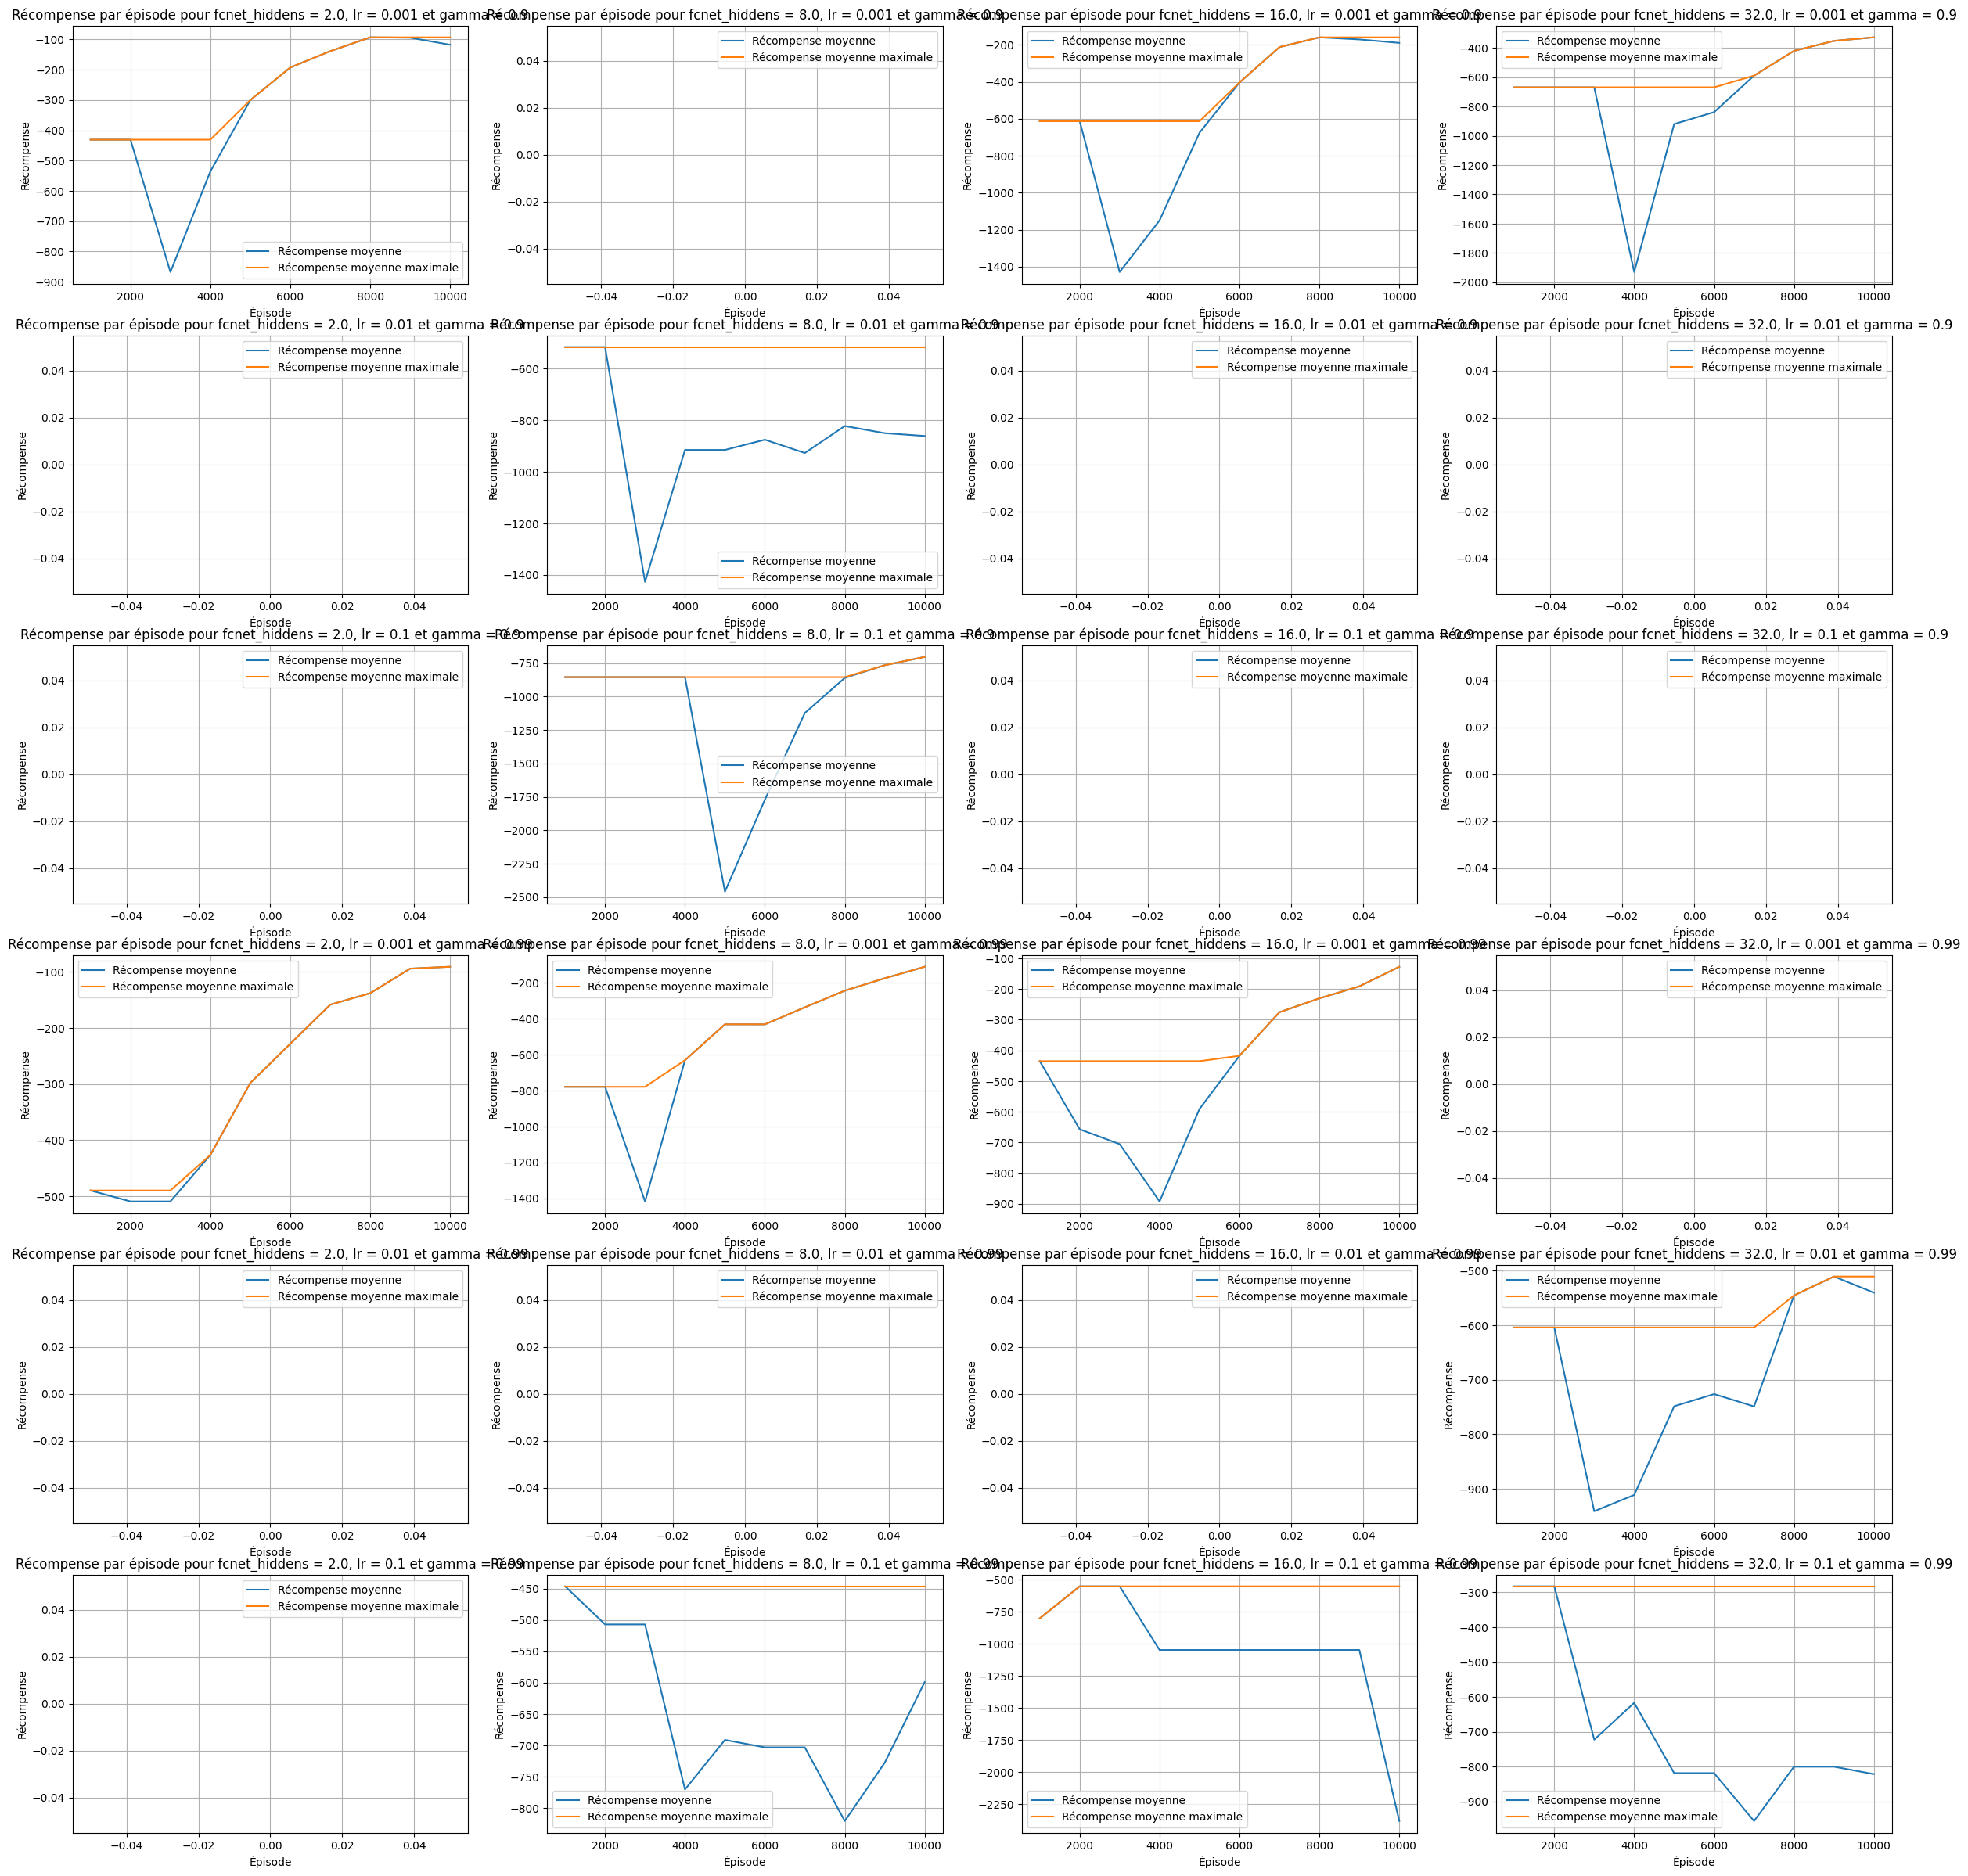

In [27]:
comparison_plot_3(results,
                  "fcnet_hiddens", [2., 8., 16., 32.],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99]
                 )

In [5]:
config = (
    DQNConfig()
    .environment(
        LineWorldEnv,
        env_config = {'n_states' : 3}
    )
    
    .env_runners(
        # Observations are discrete (ints) -> We need to flatten (one-hot) them.
        env_to_module_connector=lambda env: FlattenObservations()
    )


    # Specify a simple tune hyperparameter sweep.
    .training(
        lr = 0.001,
        gamma = 0.99
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : [2]
        }
    )
)

algo = config.build_algo()


/home/thewalder/Documents/Stage/Dépôts/pourvu/env/lib/python3.11/site-packages/ray/rllib/algorithms/algorithm.py:515: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/thewalder/Documents/Stage/Dépôts/pourvu/env/lib/python3.11/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/thewalder/Documents/Stage/Dépôts/pourvu/env/lib/python3.11/site-packages/ray/tune/logger/uni

## Essai RLLib

In [3]:
# Configure the algorithm.
config = (
    DQNConfig()
    .environment(
        LineWorldEnv,
        env_config = {'n_states' : 3},
    )
    
    .env_runners(
        # Observations are discrete (ints) -> We need to flatten (one-hot) them.
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    # Specify a simple tune hyperparameter sweep.
    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99])
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[2], [8], [16], [32]])
        }
    )
)



# Create a Tuner instance to manage the trials.
tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    # Specify a stopping criterion. Note that the criterion has to match one of the
    # pretty printed result metrics from the results returned previously by
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 10000},
    ),
)
# Run the Tuner and capture the results.
results = tuner.fit()


2025-06-13 14:51:35,090	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=47024) 2025-06-13 14:51:40,443	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=47024) 2025-06-13 14:51:41,126	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `

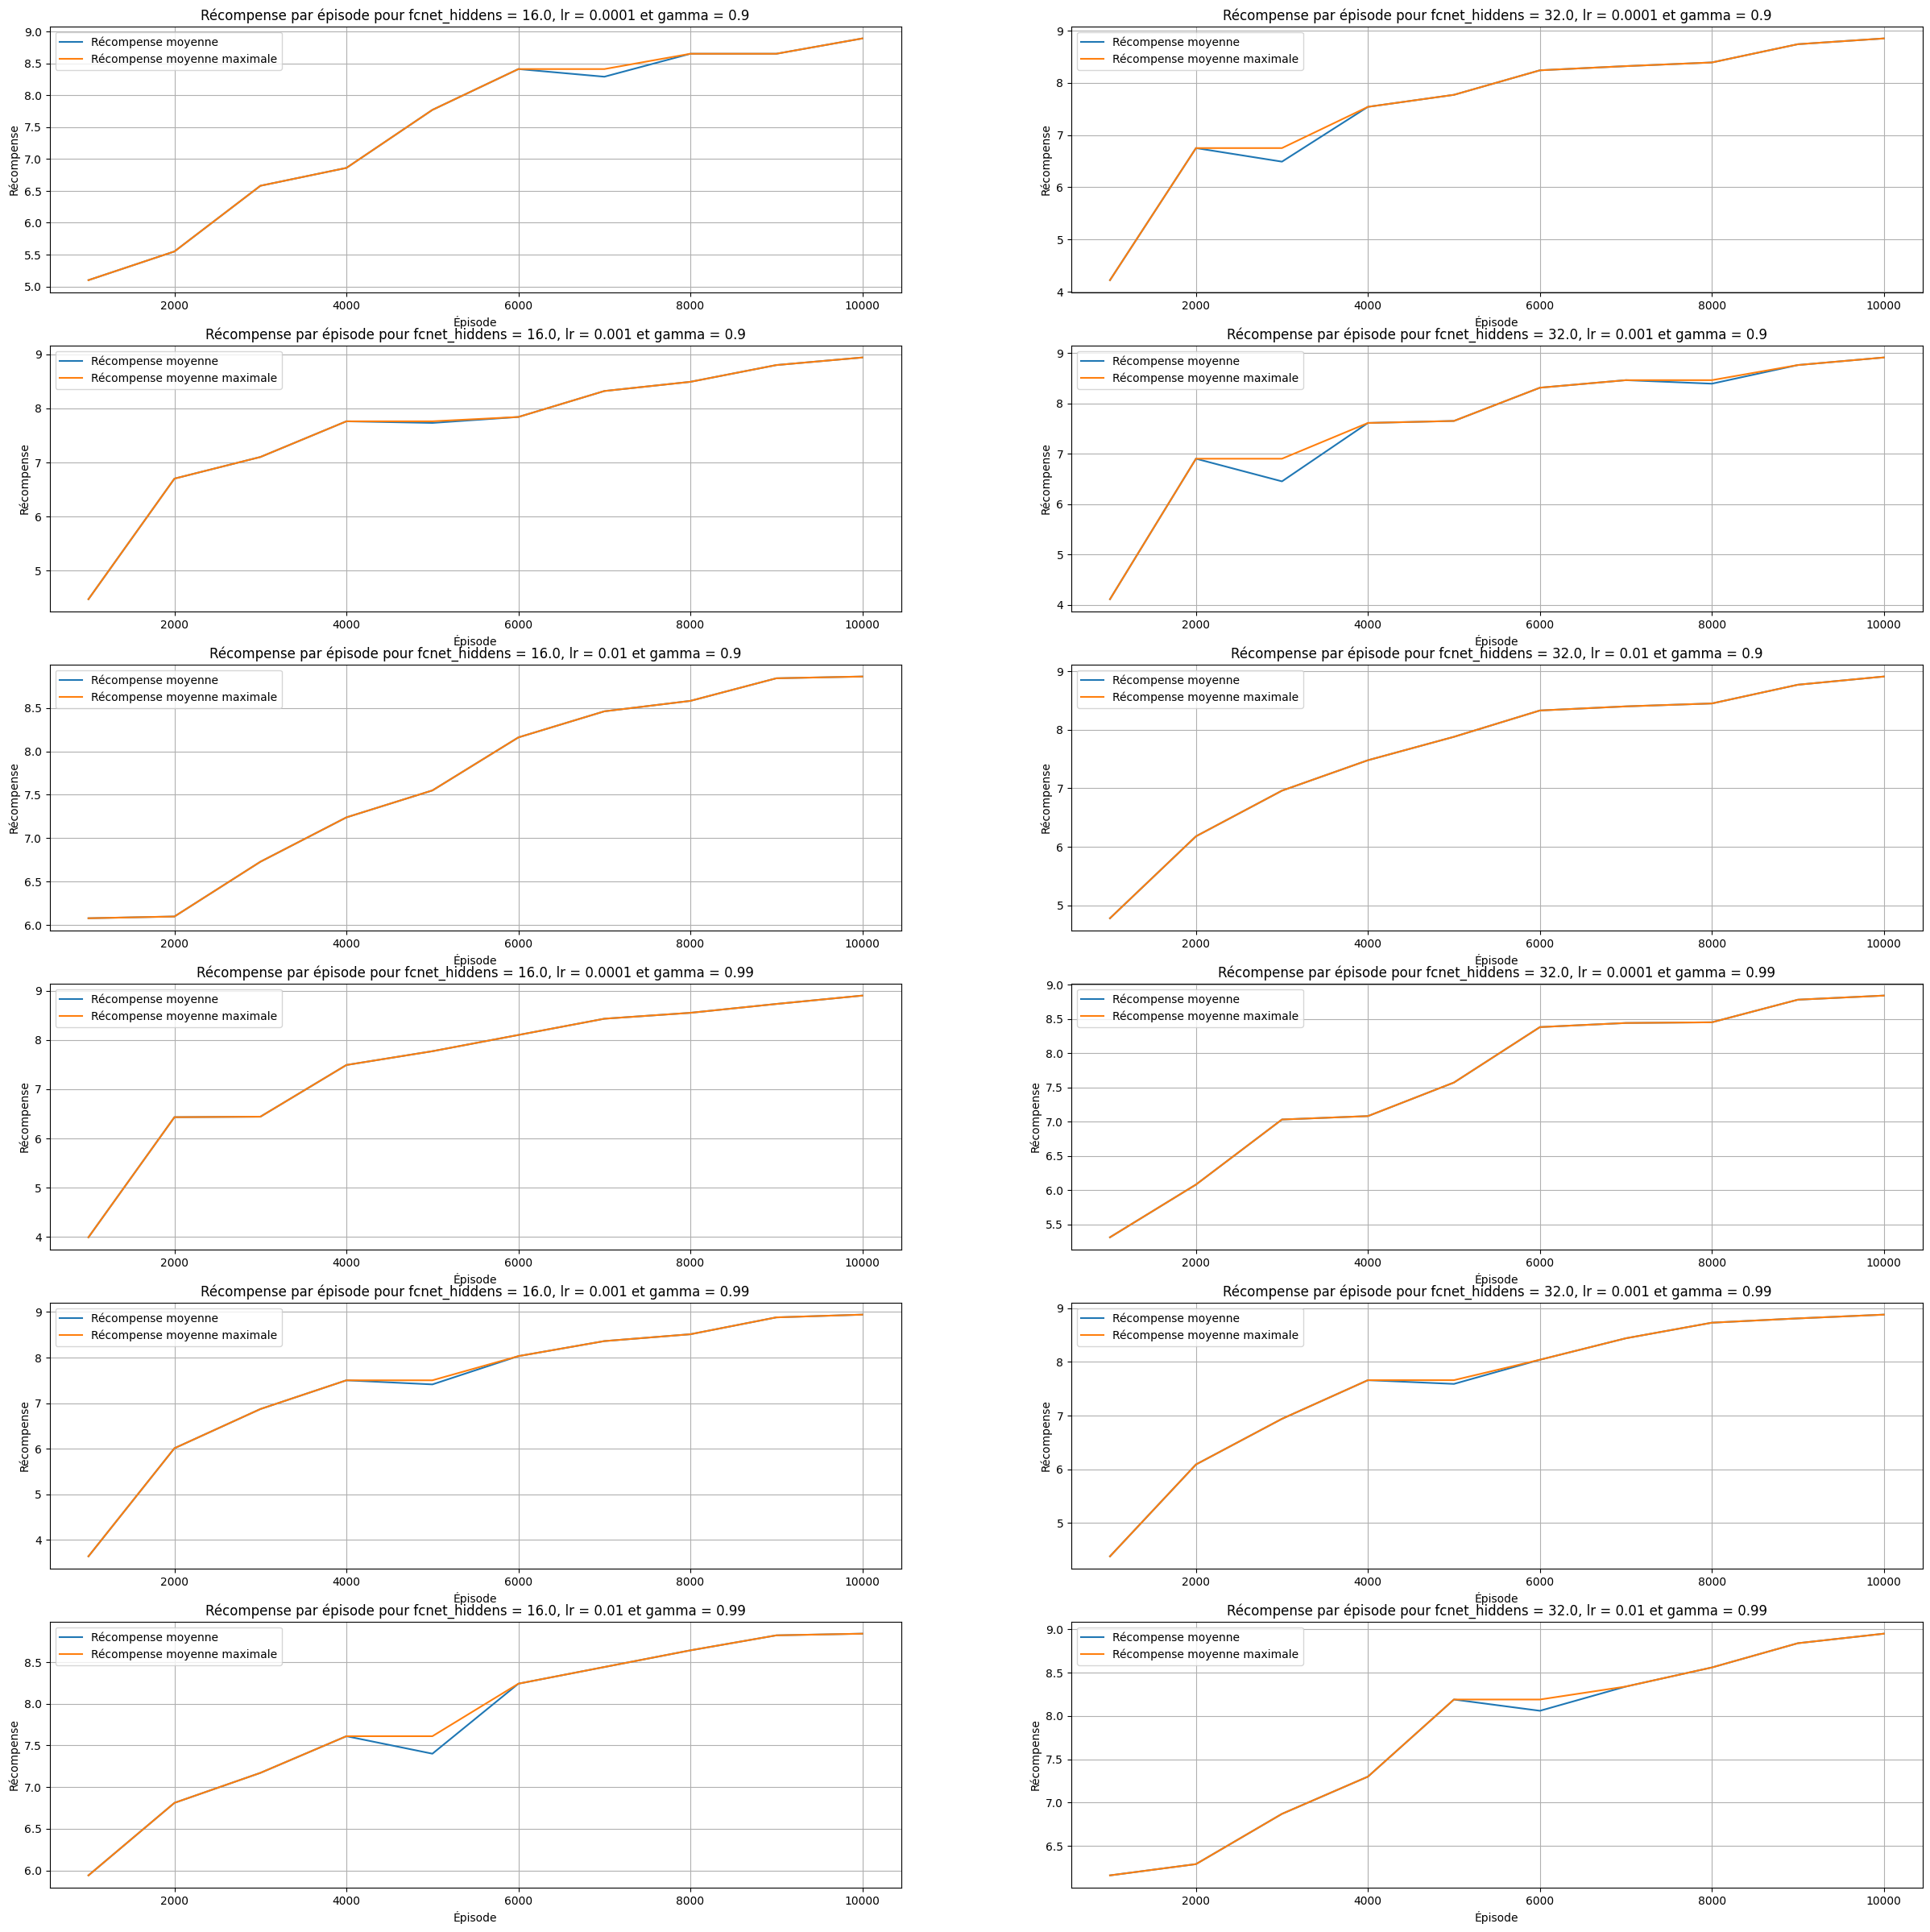

In [4]:
comparison_plot_3(results,
                  "fcnet_hiddens", [16., 32.],
                  "lr", [0.0001, 0.001, 0.01],
                  "gamma", [0.9, 0.99]
                 )

In [5]:
config = (
    DQNConfig()
    .environment(
        LineWorldEnv,
        env_config = {'n_states' : 3},
    )
    
    .env_runners(
        # Observations are discrete (ints) -> We need to flatten (one-hot) them.
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    # Specify a simple tune hyperparameter sweep.
    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99])
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[2], [8], [16], [32]])
        }
    )
)

NameError: name 'module' is not defined